# 2. Location Type Survey Statistics

In [18]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/add_treatment_to_df.R")
source("../util/samples_processing.R")

TREATMENT_DATES <- read_csv("../raw-data/treatment_dates.csv", col_names = TRUE)
ALL_PARTICIPANTS_METADATA <- read_rds("../R-table/ALL_PARTICIPANTS_METADATA.rds")
PERSONAL_EXPOSURE <- read_rds("../R-table/PERSONAL_EXPOSURE_TRAVEL_REMOVED.rds")

Rows: 221 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): purifier_group, sub_period, treatment, treatment_boundary
dbl  (2): period_id, treatment_order
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 221 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): purifier_group, sub_period, treatment, treatment_boundary
dbl  (2): period_id, treatment_order
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
locations_data <- process_data_file(
    file_path = "../raw-data/locations.csv",
    ALL_PARTICIPANTS_METADATA = ALL_PARTICIPANTS_METADATA
)
locations_data <- remove_duplicate_locations(data = locations_data)

## 2.1. Data availability - daily survey responses

In [20]:
# Max possible days (from treatment calendar)
max_days_df <- TREATMENT_DATES |>
  filter(!treatment_boundary %in% c("before_start_first_half", "before_start_second_half")) |>
  group_by(period_id) |>
  summarise(total_days = n_distinct(date), .groups = "drop") |>
  select(period_id, total_days)

location_survey_days <- locations_data |>
  filter(location_method == "survey") |>
  mutate(start_date = as_date(start_date)) |>
  distinct(pseudonym, period_id, survey_date = start_date)

survey_data_availability_by_participant <- location_survey_days |>
  group_by(pseudonym, period_id) |>
  summarise(days_with_survey = n(), .groups = "drop") |>
  arrange(period_id, pseudonym) |>
  left_join(max_days_df, by = c("period_id")) |>
  mutate(percentage = (days_with_survey / total_days) * 100) |>
  select(-period_id)
  
head(survey_data_availability_by_participant, n = 5)

pseudonym,days_with_survey,total_days,percentage
<chr>,<int>,<int>,<dbl>
apple3,28,34,82.35294
banana8,28,34,82.35294
burger4,28,34,82.35294
carrot7,24,34,70.58824
elephant1,28,34,82.35294


mean,sd,median,q25,q75
<dbl>,<dbl>,<int>,<dbl>,<dbl>
27.2439,1.771729,28,28,28


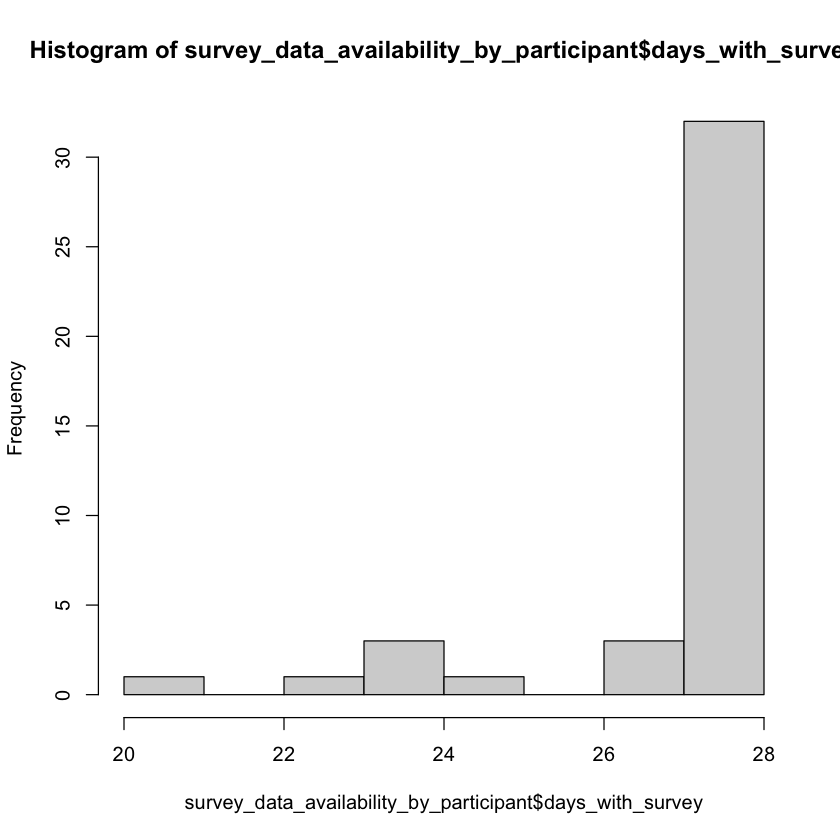

In [21]:
survey_data_availability_by_participant |>
  summarise(
    mean = mean(days_with_survey, na.rm = TRUE),
    sd = sd(days_with_survey, na.rm = TRUE),
    median = median(days_with_survey, na.rm = TRUE),
    q25 = quantile(days_with_survey, 0.25, na.rm = TRUE),
    q75 = quantile(days_with_survey, 0.75, na.rm = TRUE),
    .groups = "drop"
  )

hist(survey_data_availability_by_participant$days_with_survey)

## 2.2. Location type percentage

In [22]:
LOCATION_TYPE_STATS <- PERSONAL_EXPOSURE |>
  group_by(location_type) |>
  summarise(
    percent = round(100 * n() / nrow(PERSONAL_EXPOSURE),2),
    .groups = "drop"
  ) 
LOCATION_TYPE_STATS

location_type,percent
<chr>,<dbl>
home,61.95
indoors,30.80
outdoors,7.25
